# Exploratory plots

Figures comparing canopy height with explanatory variables

## Import libraries

In [1]:
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import shap
import lightgbm as lgb
import statsmodels.formula.api as smf
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, root_mean_squared_error

## load training cvs

In [2]:
df = pd.read_csv('CH_combined_training_data.csv')
df = df.drop('Unnamed: 0', axis=1)

## Distribution of canopy height

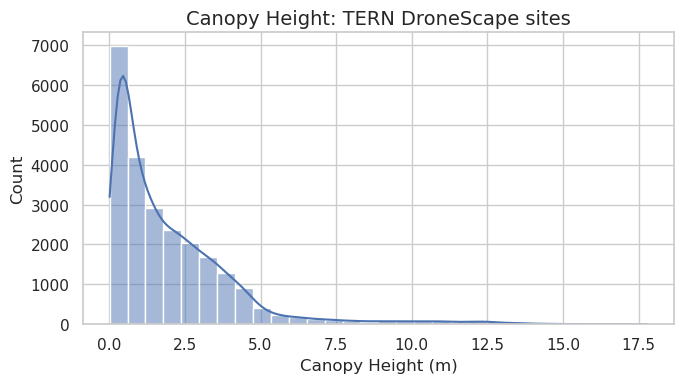

In [3]:
# Set a nice style
sns.set_theme(style="whitegrid")

# Create the histogram
plt.figure(figsize=(7, 4))
sns.histplot(df['canopy_height'], kde=True, bins=30)

# Add labels and title
plt.xlabel("Canopy Height (m)", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.title("Canopy Height: TERN DroneScape sites", fontsize=14)

plt.tight_layout()
plt.show()


## Scatter plots

#### VH

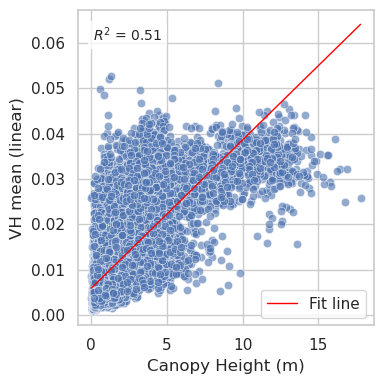

In [4]:
plt.figure(figsize=(4, 4))
x = df["canopy_height"]
y = df["VH_mean"]
y = 10 ** (y / 10)

sns.scatterplot(y=y, x=x, alpha=0.6)

weights = np.polyfit(x, y, 1)
model = np.poly1d(weights)
results = smf.ols(formula="y ~ model(x)", data=df).fit()
sns.lineplot(
    x=x,
    y=model(x),
    color="red",
    lw=1,
    label='Fit line'
)

plt.text(
    0.05, 0.95,
    f"$R^2$ = {results.rsquared:.2f}",
    transform=plt.gca().transAxes,
    fontsize=10,
    verticalalignment="top",
    bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8)
)

plt.xlabel("Canopy Height (m)")
plt.ylabel("VH mean (linear)")
plt.tight_layout();

#### RVI

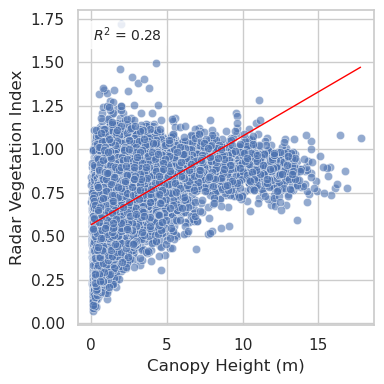

In [5]:
plt.figure(figsize=(4, 4))
x = df["canopy_height"]
y = df["RVI"]

sns.scatterplot(y=y, x=x, alpha=0.6)

weights = np.polyfit(x, y, 1)
model = np.poly1d(weights)
results = smf.ols(formula="y ~ model(x)", data=df).fit()
sns.lineplot(
    x=x,
    y=model(x),
    color="red",
    lw=1,
)

plt.text(
    0.05, 0.95,
    f"$R^2$ = {results.rsquared:.2f}",
    transform=plt.gca().transAxes,
    fontsize=10,
    verticalalignment="top",
    bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8)
)

plt.xlabel("Canopy Height (m)")
plt.ylabel("Radar Vegetation Index")
plt.tight_layout();

#### kNDVI

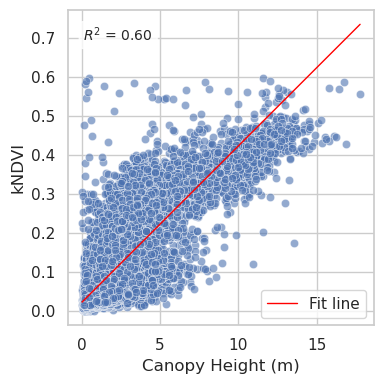

In [6]:
plt.figure(figsize=(4, 4))
x = df["canopy_height"]
y = df["kNDVI"]

sns.scatterplot(y=y, x=x, alpha=0.6)

weights = np.polyfit(x, y, 1)
model = np.poly1d(weights)
results = smf.ols(formula="y ~ model(x)", data=df).fit()
sns.lineplot(
    x=x,
    y=model(x),
    color="red",
    lw=1,
    label='Fit line'
)

plt.text(
    0.05, 0.95,
    f"$R^2$ = {results.rsquared:.2f}",
    transform=plt.gca().transAxes,
    fontsize=10,
    verticalalignment="top",
    bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8)
)

plt.xlabel("Canopy Height (m)")
plt.ylabel("kNDVI")
plt.tight_layout();

## Feature importance

In [7]:
x_vars = list(df.columns)
x_vars.remove('canopy_height')

In [8]:
X = df[x_vars]
y = df['canopy_height']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define LightGBM regressor
model = lgb.LGBMRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=-1,     
    num_leaves=31,
    n_jobs=-1,
    random_state=42,
    verbose=-1
)

model.fit(X_train, y_train)

# Evaluate
y_pred = model.predict(X_test)

r2=r2_score(y_test, y_pred)
rmse=root_mean_squared_error(y_test, y_pred)
print(f"R²: {r2:.2f}")
print(f"RMSE: {rmse:.2f}")

R²: 0.86
RMSE: 0.79


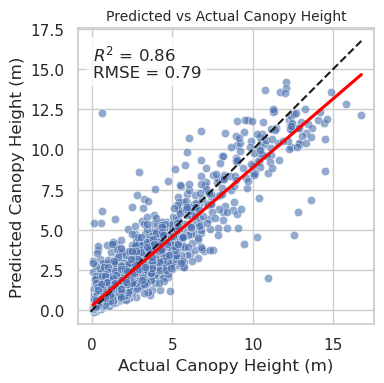

In [9]:
plt.figure(figsize=(4, 4))

# Scatter plot of predicted vs actual
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6)

# 1:1 line
lims = [
    np.min([y_test.min(), y_pred.min()]),
    np.max([y_test.max(), y_pred.max()]),
]
plt.plot(lims, lims, 'k--', label="1:1 line")

# Linear regression fit line
sns.regplot(x=y_test, y=y_pred, scatter=False, ci=None, color="red", label="Fit line")

plt.text(
    0.05, 0.95,
    f"$R^2$ = {r2:.2f}\nRMSE = {rmse:.2f}",
    transform=plt.gca().transAxes,
    fontsize=12,
    verticalalignment="top",
    bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8)
)

plt.xlabel("Actual Canopy Height (m)")
plt.ylabel("Predicted Canopy Height (m)")
plt.title("Predicted vs Actual Canopy Height", fontsize=10)
plt.axis("equal")  # Makes x and y scale equal for fair comparison
plt.tight_layout();

In [10]:
# SHAP explainers can work with tree-based models like RandomForest
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X)

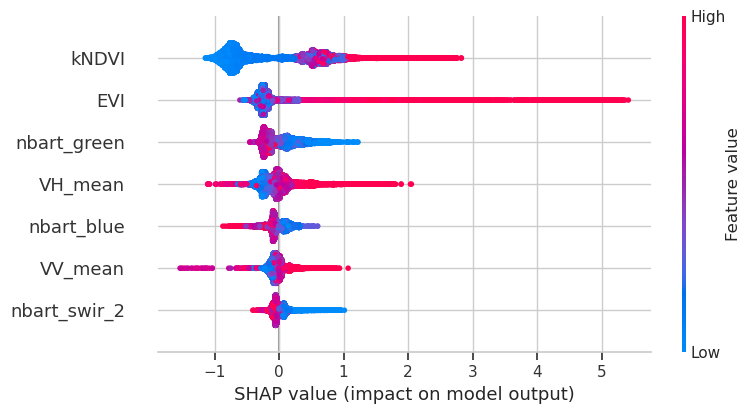

In [13]:
#Bar plot of mean absolute SHAP values
shap.summary_plot(shap_values, X, feature_names=x_vars, max_display=7)